In [128]:
%matplotlib inline

import gym
import matplotlib
import numpy as np
import sys

from collections import defaultdict
if "../" not in sys.path:
  sys.path.append("../") 
from lib.envs.blackjack import BlackjackEnv
from lib import plotting

matplotlib.style.use('ggplot')

In [129]:
env = BlackjackEnv()

In [130]:
def create_random_policy(nA):
    """
    Creates a random policy function.
    
    Args:
        nA: Number of actions in the environment.
    
    Returns:
        A function that takes an observation as input and returns a vector
        of action probabilities
    """
    A = np.ones(nA, dtype=float) / nA
    def policy_fn(observation):
        return A
    return policy_fn

In [131]:
def create_greedy_policy(Q):
    """
    Creates a greedy policy based on Q values.
    
    Args:
        Q: A dictionary that maps from state -> action values
        
    Returns:
        A function that takes an observation as input and returns a vector
        of action probabilities.
    """
    
    def policy_fn(observation):
        action_values = Q[observation]
        action_probs = np.zeros(len(action_values), dtype=float)
        # # multi maxs version
        # indicies = np.argwhere(action_values == np.max(action_values)).flatten()
        # action_probs[indicies] = 1.0/len(indicies)
        # single max version
        max_a = np.argmax(action_values)
        action_probs[max_a] = 1.0
        return action_probs
    return policy_fn

In [132]:
def mc_control_importance_sampling(env, num_episodes, behavior_policy, discount_factor=1.0):
    """
    Monte Carlo Control Off-Policy Control using Weighted Importance Sampling.
    Finds an optimal greedy policy.
    
    Args:
        env: OpenAI gym environment.
        num_episodes: Number of episodes to sample.
        behavior_policy: The behavior to follow while generating episodes.
            A function that given an observation returns a vector of probabilities for each action.
        discount_factor: Gamma discount factor.
    
    Returns:
        A tuple (Q, policy).
        Q is a dictionary mapping state -> action values.
        policy is a function that takes an observation as an argument and returns
        action probabilities. This is the optimal greedy policy.
    """
    
    # The final action-value function.
    # A dictionary that maps state -> action values
    Q = defaultdict(lambda: np.zeros(env.action_space.n))

    # The sum of cumlative importance sampling correction for each state-action pairs in all episodes
    C = defaultdict(lambda: np.zeros(env.action_space.n))

    # Our greedily policy we want to learn
    target_policy = create_greedy_policy(Q)

    for i_episode in range(1,num_episodes+1):
        # Print out which episode we're on, useful for debugging.
        if i_episode % 1000 == 0:
            print("\rEpisode {}/{}.".format(i_episode, num_episodes), end="")
            sys.stdout.flush()

        episode = []
        state = env.reset()
        first_s_a_indices = {}
        for t in range(100):
            # follow the behavior policy to sample action
            behaviour_probs = behavior_policy(state)
            action = np.random.choice(np.arange(len(behaviour_probs)), p=behaviour_probs)
            next_state, reward, down, _ = env.step(action)
            # importance sampling correction
            target_probs = target_policy(state)
            correction = target_probs[action]/behaviour_probs[action]
            episode.append((state,action,reward,correction))
            if (tuple(state),action) not in first_s_a_indices:
                first_s_a_indices[(tuple(state),action)] = t
            if down:
                break
            state = next_state
        
        # reversed iteration and calculate returns
        G = 0.0
        # cumulative importance sampling correction
        W = 1.0
        for i in reversed(range(len(episode))):
            s,a,r,c = episode[i]
            # 剪枝
            # 如果由 behaviour policy 采样的action 与target policy的不一样, 
            # 也即target policy采取这一动作的概率 pi=0,重要性修正系数correction=pi/u=0,
            # 那么往前的所有(s,a)的重要性修正系数都为0,不需要再计算 (这些样本不符合target policy的目标分布)
            if a != np.argmax(target_policy(s)):
                break
            G = r + discount_factor*G
            W = W*c
            if first_s_a_indices[(tuple(s),a)] == i:
                C[s][a]+=W
                # 重要性采样下,每个Q值都带有一个连乘的重要性修正系数 W
                # 因此,增量法计算平均时,用 W/sum(W) 代替 1/N_count(s,a)
                # 1/N_count -> W/sum(W)
                Q[s][a]+=(W/C[s][a])*(G-Q[s][a])
           
    return Q, target_policy

In [133]:
random_policy = create_random_policy(env.action_space.n)
Q, policy = mc_control_importance_sampling(env, num_episodes=500000, behavior_policy=random_policy)

Episode 500000/500000.

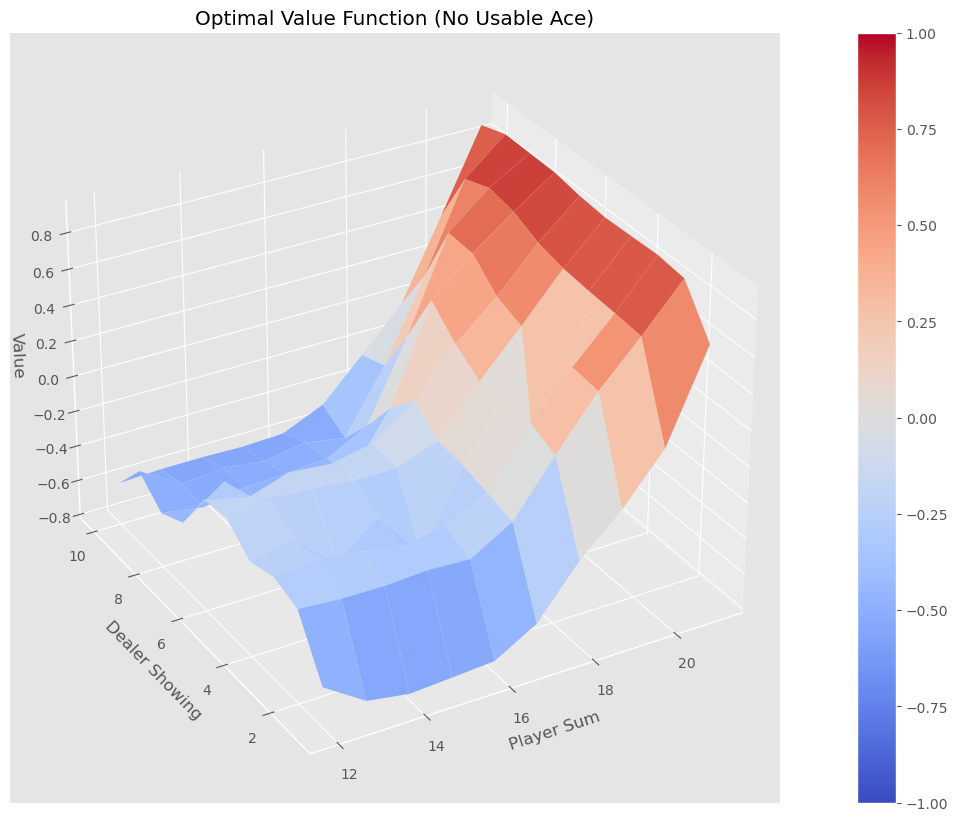

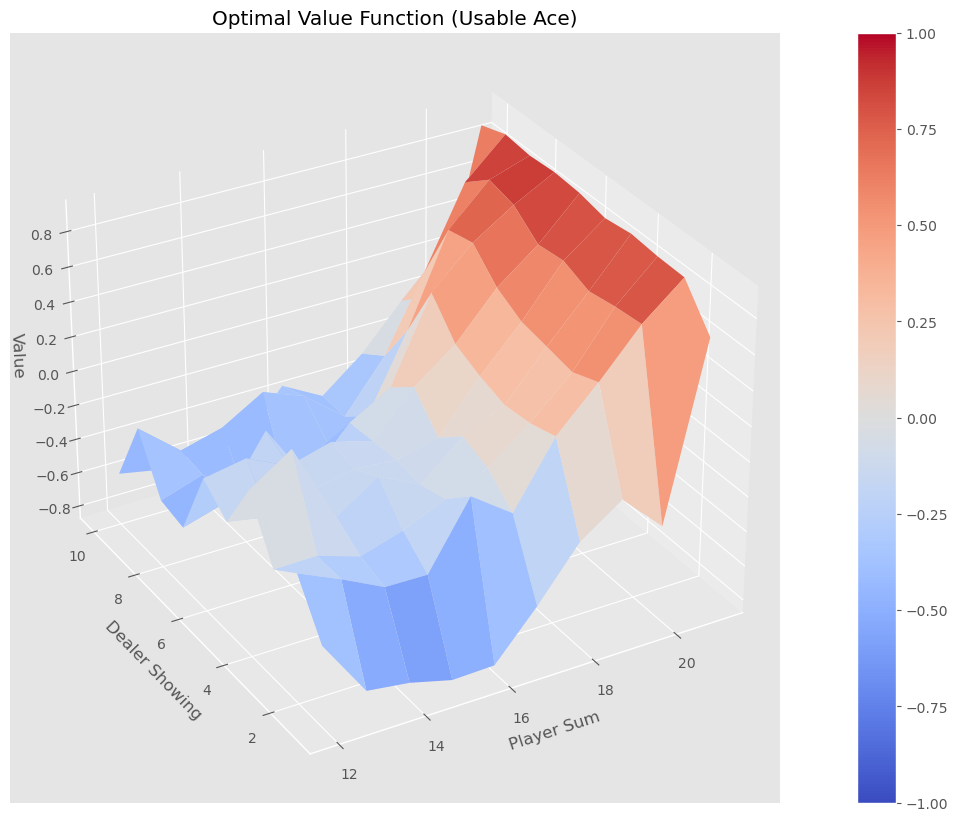

In [134]:
# For plotting: Create value function from action-value function
# by picking the best action at each state
V = defaultdict(float)
for state, action_values in Q.items():
    action_value = np.max(action_values)
    V[state] = action_value
plotting.plot_value_function(V, title="Optimal Value Function")